In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import re
from machine_learning import *
from hyperion_utils import *

In [4]:
myDfs = readDfs()

In [5]:
print(myDfs['Description_tables_variables'][['Tables', 'Variable', 'LabelTranslated', 'Label']].to_string())

         Tables                          Variable                                                                                      LabelTranslated                                                                                                 Label
0           ADL                            SUBJID                                                                     Subject Identifier for the Study                                                                      Subject Identifier for the Study
1           ADL                             ADL_0                                                                    Has the ADL score been completed?                                                                      Le score ADL a t-il été complété
2           ADL                        ADL_1_TEMP                                                      Personal hygiene (intermediate field for entry)                                                  Hygiène corporelle (champ intermediaire p

In [6]:
bio_data_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[52:76])
bio_data_columns.append('SUBJID')
bio_data_columns_descr = list(myDfs['Description_tables_variables']['Label'].iloc[52:76])
bio_visit_column = 'VISIT'
cpc_column = 'CPC_SC3'
group_colums = ['V0_BRAS2', 'groupe']
ds_columns = 'DS_DATA_REFUS'
ecg_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[137:154])
ecg_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[137:154])
j0_drop_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[362:384])
j0_reflex_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[273:285])
j0_reflex_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[273:285])
sofa_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[586:593])
sofa_columns.append('SUBJID')
ei_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[158:168])
ei_columns = ei_columns + (['SUBJID', 'EI_ARYTHMI', 'EI_ANTIEPILEPTIQ'])

In [39]:
myPredictorsDf = pd.read_csv('../predictorsDf.csv')

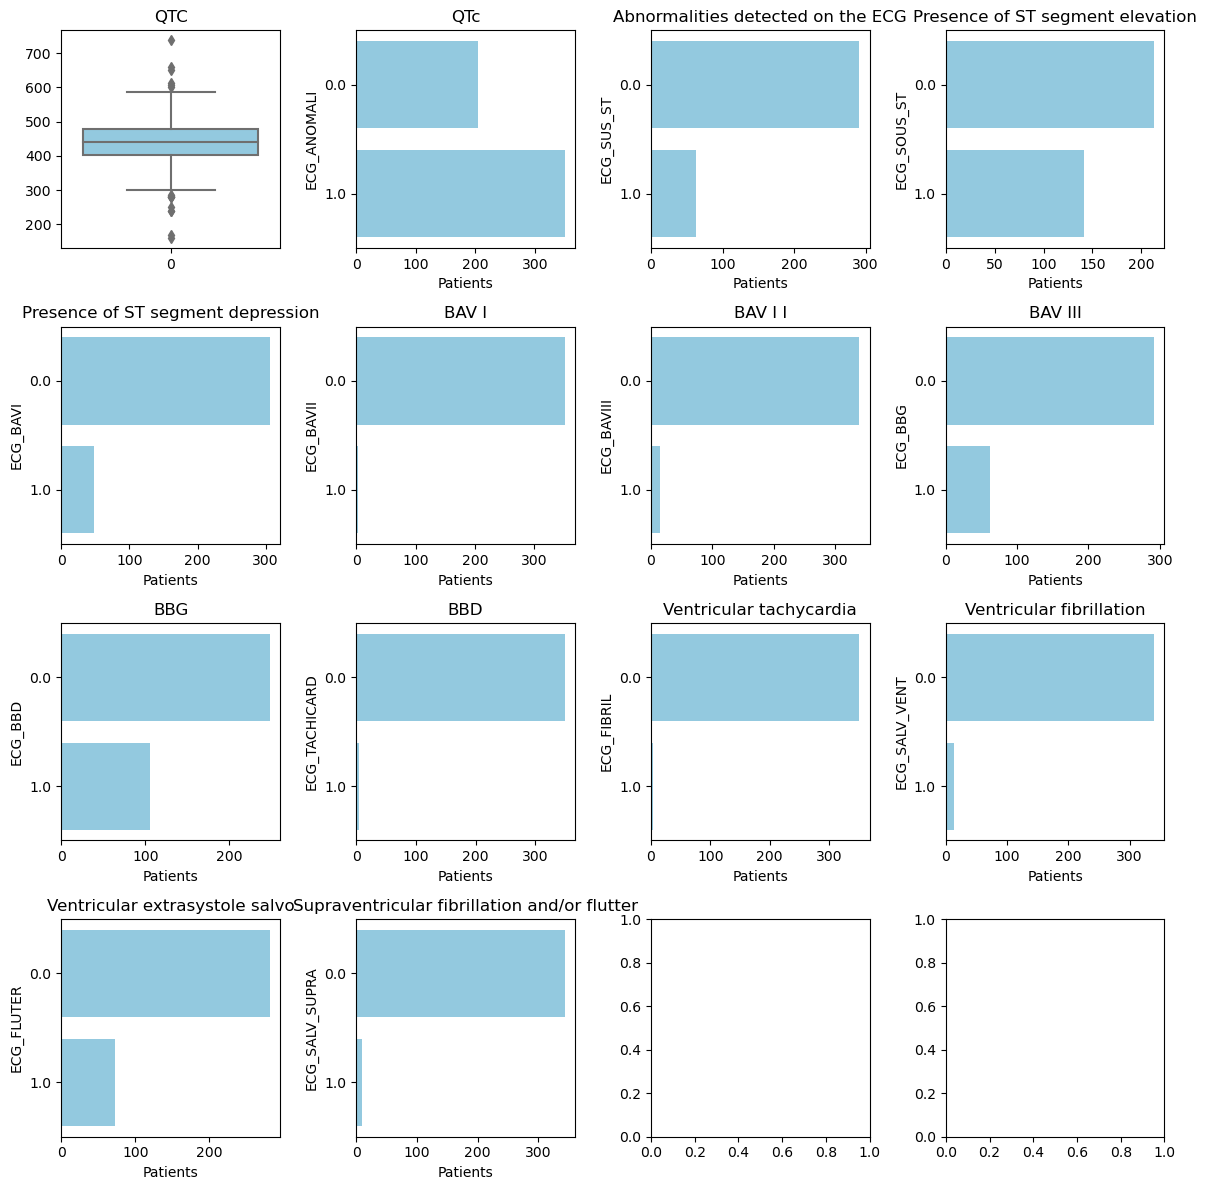

In [10]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))
ecg_columns2 = ecg_columns[3:]
for i, value in enumerate(ecg_columns2):
  myAxis = axs[i // 4, i % 4]
  if value == 'ECG_QTC':
    sns.boxplot(myPredictorsDf['ECG_QTC'], ax=myAxis, color='skyblue')
    myAxis.set_title('QTC')
  else:
    myGroup = getGroupByPatients(myPredictorsDf, value, value)
    sns.barplot(y = value, x = 'Patients', data=myGroup.reset_index(), ax=myAxis, color='skyblue', orient='h')
    myAxis.set_title(ecg_columns_descr[i + 2])
plt.tight_layout()
plt.show()

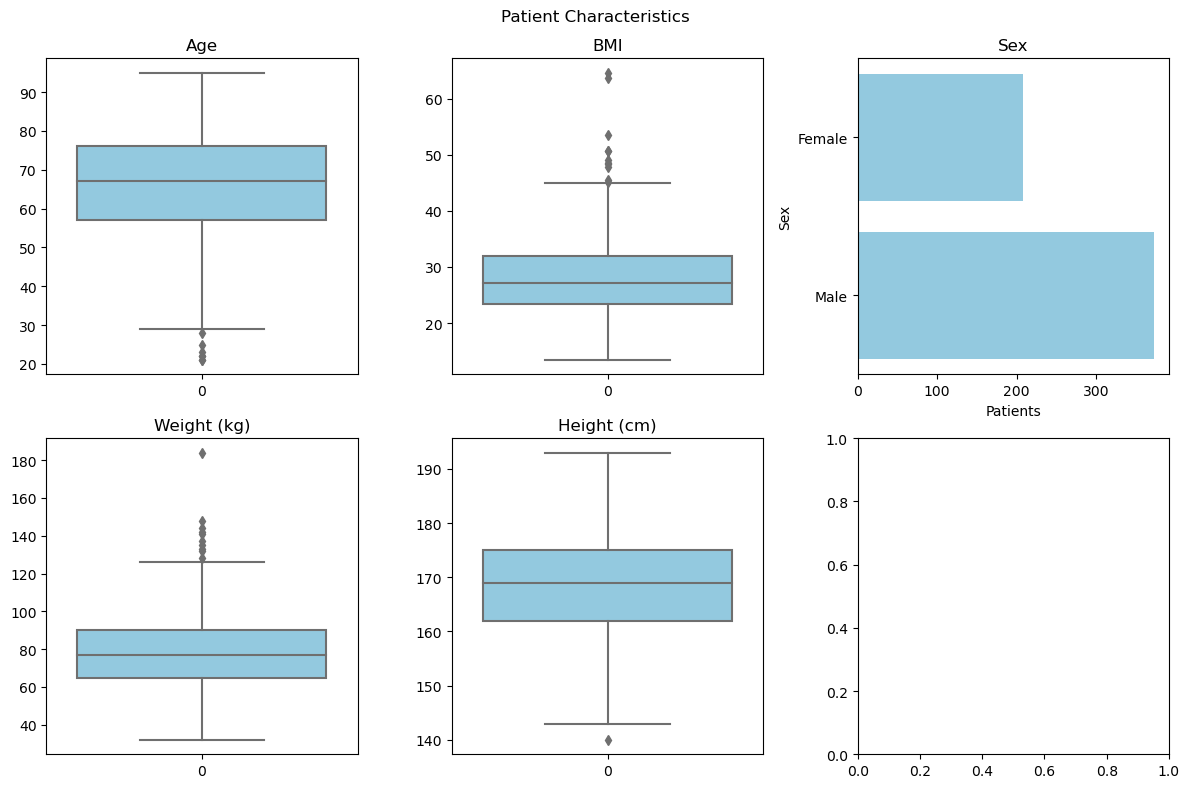

In [37]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
sns.boxplot(myPredictorsDf['J0_AGE'], ax=axs[0][0], color='skyblue')
axs[0][0].set_title('Age')
sns.boxplot(myPredictorsDf['J0_BMI'], ax=axs[0][1], color='skyblue')
axs[0][1].set_title('BMI')
sns.boxplot(myPredictorsDf['J0_POIDS'], ax=axs[1][0], color='skyblue')
axs[1][0].set_title('Weight (kg)')
sns.boxplot(myPredictorsDf['J0_TAILLE'], ax=axs[1][1], color='skyblue')
axs[1][1].set_title('Height (cm)')
myColumn = 'J0_SEX'
myRename = 'Sex'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename).rename({'Homme': 'Male', 'Femme': 'Female'})
sns.barplot(y = 'Sex', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][2], color='skyblue')
axs[0][2].set_title('Sex')
fig.suptitle('Patient Characteristics')
plt.tight_layout()
plt.show()

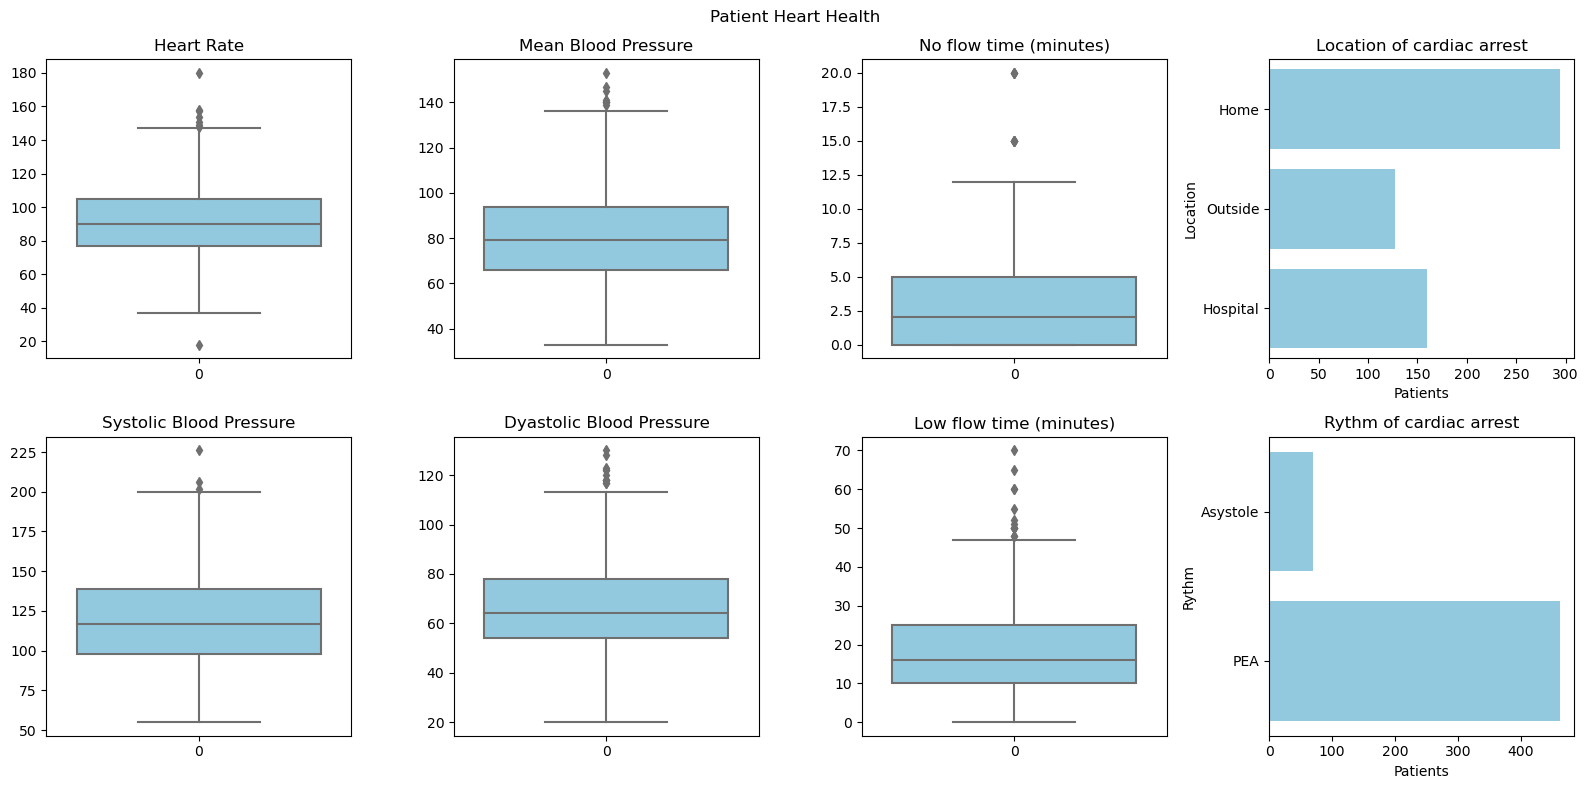

In [38]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
sns.boxplot(myPredictorsDf['J0_FC'], ax=axs[0][0], color='skyblue')
axs[0][0].set_title('Heart Rate')
sns.boxplot(myPredictorsDf['J0_PAM'], ax=axs[0][1], color='skyblue')
axs[0][1].set_title('Mean Blood Pressure')
sns.boxplot(myPredictorsDf['J0_PAS'], ax=axs[1][0], color='skyblue')
axs[1][0].set_title('Systolic Blood Pressure')
sns.boxplot(myPredictorsDf['J0_PAD'], ax=axs[1][1], color='skyblue')
axs[1][1].set_title('Dyastolic Blood Pressure')
sns.boxplot(myPredictorsDf['J0_NOFLOW'], ax=axs[0][2], color='skyblue')
axs[0][2].set_title('No flow time (minutes)')
sns.boxplot(myPredictorsDf['J0_LOWFLOW'], ax=axs[1][2], color='skyblue')
axs[1][2].set_title('Low flow time (minutes)')
fig.suptitle('Patient Heart Health')
# ADD acr location and rythm heere
myColumn = 'J0_LIEU_ACR'
myRename = 'Location'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename).rename({1: 'Home', 2: 'Outside', 3: 'Hospital'})
sns.barplot(y = 'Location', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][3], color='skyblue')
axs[0][3].set_title('Location of cardiac arrest')

myColumn = 'J0_RYTHM'
myRename = 'Rythm'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename).rename({1: 'Asystole', 2: 'PEA'})
sns.barplot(y = 'Rythm', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][3], color='skyblue')
axs[1][3].set_title('Rythm of cardiac arrest')

plt.tight_layout()
plt.show()

In [14]:
myColumn = 'J0_RYTHM'
myRename = 'Rythm'
getGroupByPatients(myPredictorsDf, myColumn, myRename).rename({1: 'Asystole', 2: 'PEA'})

,Patients
Rythm,
Asystole,69
PEA,462


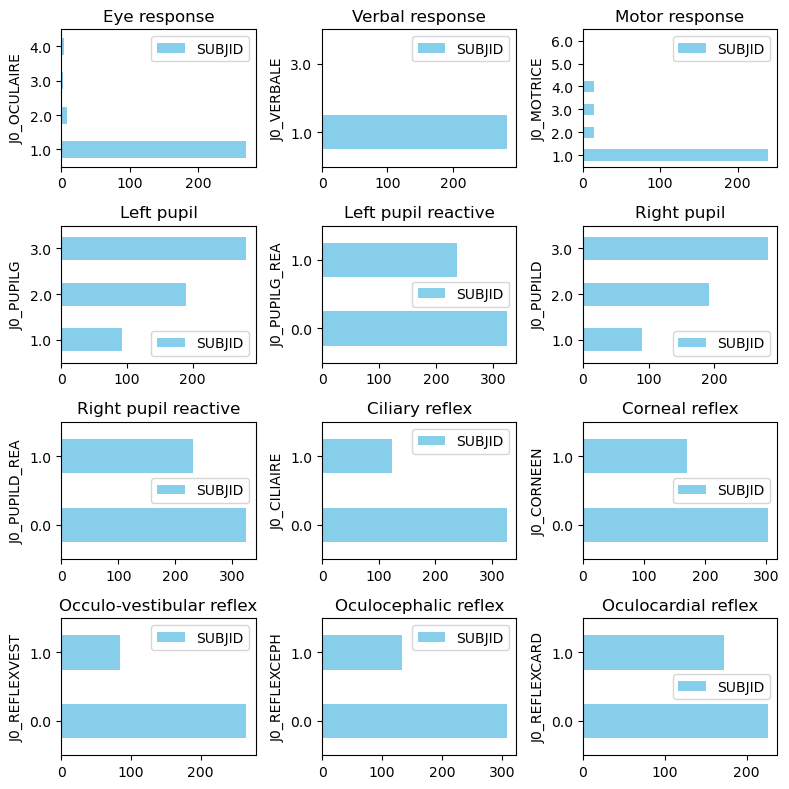

In [15]:
fig, axs = plt.subplots(4, 3, figsize=(8, 8))
for i, value in enumerate(j0_reflex_columns):
  myPredictorsDf.groupby(value).agg({'SUBJID': 'count'}).plot(kind='barh', color = ['skyblue'], title = j0_reflex_columns_descr[i], ax = axs[i // 3, i % 3]) # change this to sns
plt.tight_layout()
plt.show()

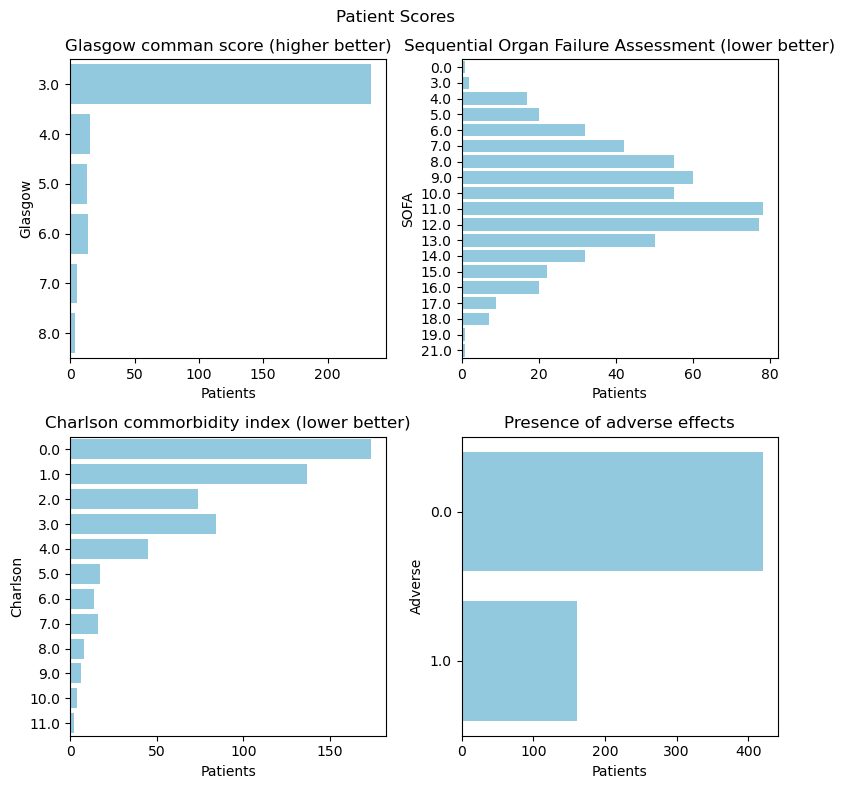

In [40]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
# ADD acr location and rythm heere
myColumn = 'J0_GLASGOW'
myRename = 'Glasgow'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'Glasgow', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][0], color='skyblue', orient='h')
axs[0][0].set_title('Glasgow comman score (higher better)')

myColumn = 'SOFA_SC1'
myRename = 'SOFA'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'SOFA', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][1], color='skyblue', orient='h')
axs[0][1].set_title('Sequential Organ Failure Assessment (lower better)')

myColumn = 'J0_CHARLSON'
myRename = 'Charlson'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'Charlson', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][0], color='skyblue', orient='h')
axs[1][0].set_title('Charlson commorbidity index (lower better)')

myColumn = 'EI_EI'
myRename = 'Adverse'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'Adverse', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][1], color='skyblue', orient='h')
axs[1][1].set_title('Presence of adverse effects')

fig.suptitle('Patient Scores')

plt.tight_layout()
plt.show()

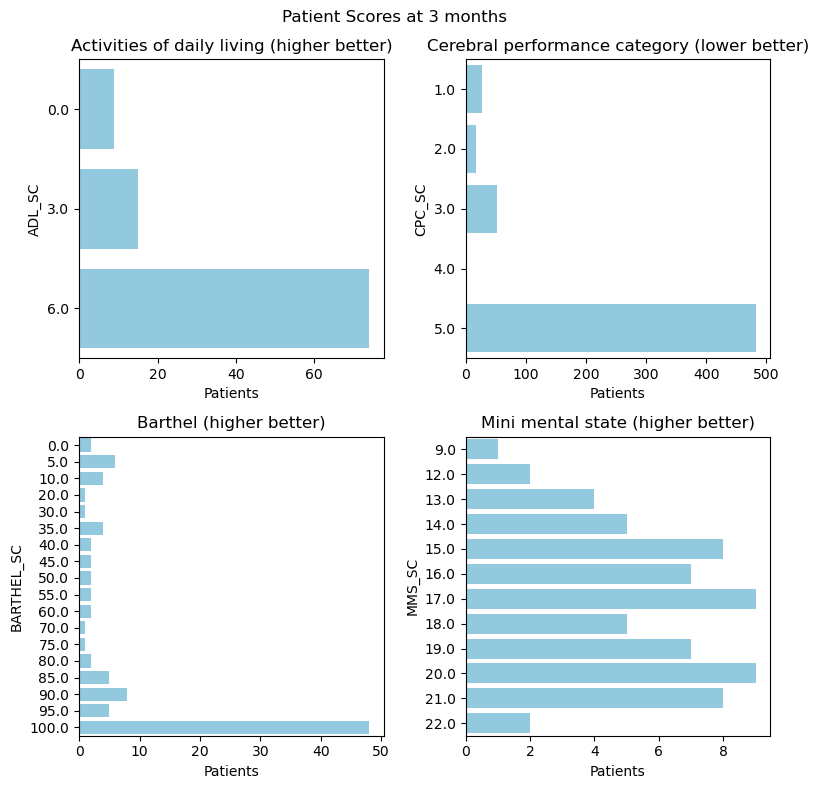

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
# ADD acr location and rythm heere
myColumn = 'ADL_SC'
myRename = 'ADL_SC'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'ADL_SC', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][0], color='skyblue', orient='h')
axs[0][0].set_title('Activities of daily living (higher better)')

myColumn = 'CPC_SC3'
myRename = 'CPC_SC'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'CPC_SC', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][1], color='skyblue', orient='h')
axs[0][1].set_title('Cerebral performance category (lower better)')

myColumn = 'BARTHEL_SC'
myRename = 'BARTHEL_SC'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'BARTHEL_SC', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][0], color='skyblue', orient='h')
axs[1][0].set_title('Barthel (higher better)')

myColumn = 'MMS_SC'
myRename = 'MMS_SC'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'MMS_SC', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][1], color='skyblue', orient='h')
axs[1][1].set_title('Mini mental state (higher better)')

fig.suptitle('Patient Scores at 3 months')

plt.tight_layout()
plt.show()

In [41]:
myPredictorsDfCorr = myPredictorsDf.copy()
myPredictorsDfCorr.drop(columns=['J0_SEX'], inplace=True)
corr = myPredictorsDfCorr.corr()
corr1 = myPredictorsDfCorr[myPredictorsDf['groupe'] == 1].corr()
corr2 = myPredictorsDfCorr[myPredictorsDf['groupe'] == 0].corr()
myDiff = corr1 - corr2
# print(corr2)

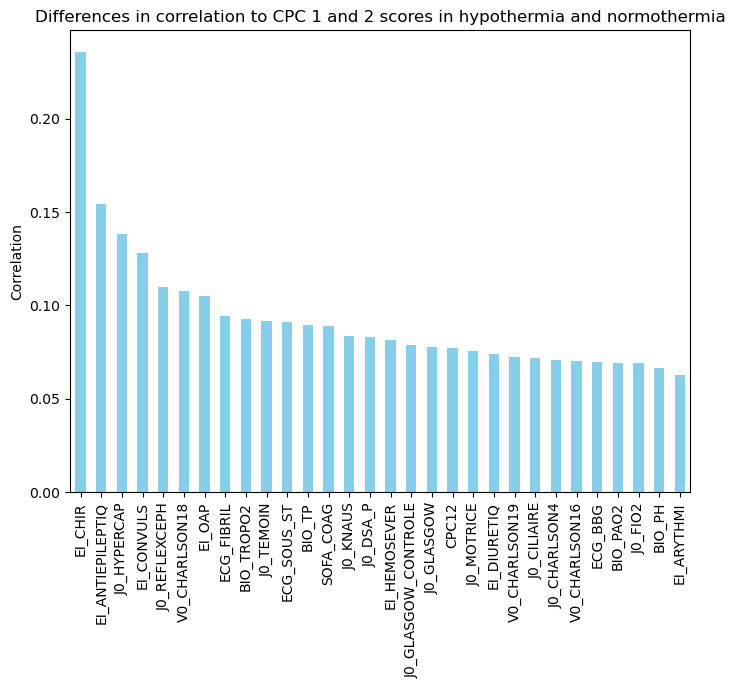

In [27]:
top_corr = corr['groupe'].abs().sort_values(ascending=False)[4:]
top_corr = top_corr[:30]
plt.figure(figsize=(8,6))
top_corr.plot(kind = 'bar', color = 'skyblue')
plt.title('Differences in correlation to CPC 1 and 2 scores in hypothermia and normothermia')
plt.ylabel('Correlation')
plt.show()

In [43]:
myPredictorsDf = getType(myPredictorsDf)

In [29]:
myPredictorsDf.groupby('Type')['J0_REFLEXVEST'].describe(percentiles=quantile_values)

,count,mean,std,min,1%,10%,25%,40%,50%,60%,75%,90%,99%,max
Type,,,,,,,,,,,,,,
CPC12HYpothermia,19.0,0.789474,0.418854,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CPC12Normothermia,10.0,0.500000,0.527046,0.0,0.0,0.0,0.0,0.0,0.5,1.0,1.0,1.0,1.0,1.0
NotCPC12Hypothermia,147.0,0.190476,0.394019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
NotCPC12Normothermia,174.0,0.206897,0.406250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


In [30]:
myPredictorsDf.groupby('Type')['J0_CILIAIRE'].describe(percentiles=quantile_values)

,count,mean,std,min,1%,10%,25%,40%,50%,60%,75%,90%,99%,max
Type,,,,,,,,,,,,,,
CPC12HYpothermia,21.0,0.809524,0.402374,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CPC12Normothermia,13.0,0.692308,0.480384,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
NotCPC12Hypothermia,200.0,0.255000,0.436955,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
NotCPC12Normothermia,217.0,0.216590,0.412873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


In [31]:
model = ols('CPC12 ~ groupe', data=myPredictorsDf).fit()
anova_table = sm.stats.anova_lm(model, typ=2) 
print(anova_table)

             sum_sq     df         F    PR(>F)
groupe     0.248257    1.0  3.483247  0.062498
Residual  41.266373  579.0       NaN       NaN


In [32]:
turkey = pairwise_tukeyhsd(endog=myPredictorsDf['CPC12'], groups=myPredictorsDf['groupe'], alpha=0.05)
print(turkey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   0.0    1.0   0.0414 0.0625 -0.0022 0.0849  False
---------------------------------------------------


In [53]:
# top_corr = corr['CPC12'].sort_values(ascending=False)[3:33]
myGroup = 1
X = sm.add_constant(myPredictorsDf.drop(columns=['CPC12', 'CPC_SC3', 'Type', 'J0_SEX', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30']).fillna(0)[myPredictorsDf['groupe'] == myGroup])#[top_corr.index])
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X)).reindex()
X_scaled.columns = X.columns
model = sm.OLS(myPredictorsDf[myPredictorsDf['groupe'] == myGroup]['CPC12'].reset_index().drop(columns='index'), X_scaled).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                  CPC12   R-squared (uncentered):                   0.561
Model:                            OLS   Adj. R-squared (uncentered):              0.056
Method:                 Least Squares   F-statistic:                              1.110
Date:                Tue, 15 Oct 2024   Prob (F-statistic):                       0.269
Time:                        06:47:29   Log-Likelihood:                          42.950
No. Observations:                 284   AIC:                                      218.1
Df Residuals:                     132   BIC:                                      772.7
Df Model:                         152                                                  
Covariance Type:            nonrobust                                                  
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

In [54]:
myGroup = 1
X = sm.add_constant(myPredictorsDf.drop(columns=['CPC12', 'CPC_SC3', 'Type', 'J0_SEX', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30']).fillna(0))#[top_corr.index])
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X)).reindex()
X_scaled.columns = X.columns
model = sm.OLS(myPredictorsDf['CPC12'].reset_index().drop(columns='index'), X_scaled).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                  CPC12   R-squared (uncentered):                   0.388
Model:                            OLS   Adj. R-squared (uncentered):              0.164
Method:                 Least Squares   F-statistic:                              1.730
Date:                Tue, 15 Oct 2024   Prob (F-statistic):                    7.99e-06
Time:                        06:47:53   Log-Likelihood:                          61.532
No. Observations:                 581   AIC:                                      188.9
Df Residuals:                     425   BIC:                                      869.8
Df Model:                         156                                                  
Covariance Type:            nonrobust                                                  
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

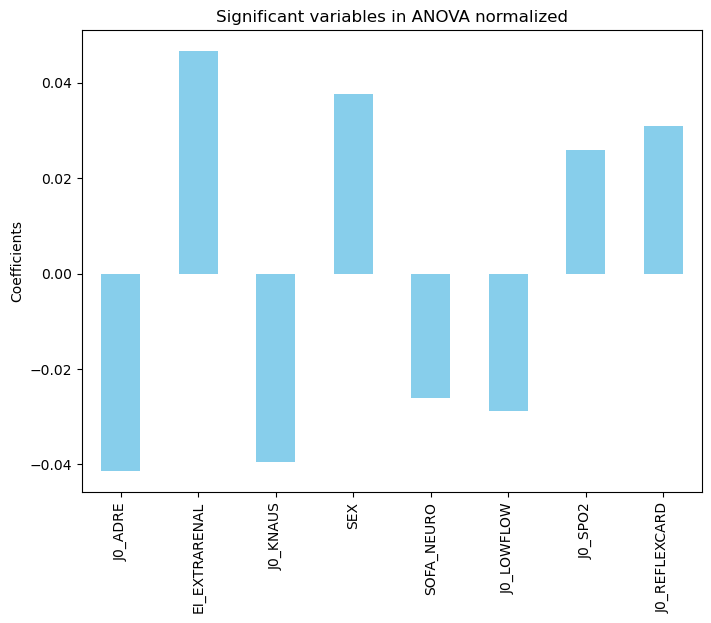

In [56]:
top_corr = model.pvalues.abs()[model.pvalues.abs() < 0.05].sort_values(ascending=True)
top_corr = model.params[top_corr.index]
plt.figure(figsize=(8,6))
top_corr.plot(kind = 'bar', color = 'skyblue')
plt.title('Significant variables in ANOVA normalized')
plt.ylabel('Coefficients')
plt.show()

In [48]:
model.pvalues.abs()[model.pvalues.abs() < 0.2]

const            1.690972e-01
groupe           4.431683e-02
J0_PAD           1.403607e-01
J0_KNAUS         2.156661e-03
J0_CHARLSON6     1.288980e-01
J0_NYHA          3.993856e-02
J0_POUMON        1.771766e-01
J0_HYPERCAP      1.762907e-01
J0_TABAC         5.711406e-02
J0_DSA_P         1.983010e-01
J0_ADRE          2.189035e-02
J0_ADRE_DOS      1.371301e-01
V0_ACR2          1.299813e-01
J0_AGREG         1.253386e-01
BIO_LEUCO        1.253481e-01
ECG_QTC          8.795599e-02
ECG_FLUTER       1.367034e-01
EI_EXTRARENAL    8.141337e-02
BARTHEL_SC       1.078724e-30
SOFA_SC7         1.871385e-02
DS_DC            1.412368e-03
SEX              6.480412e-02
dtype: float64

In [49]:
myPredictorsDf.groupby(['Type', 'J0_O2']).agg({'SUBJID': 'count'})

SUBJID
Type                 J0_O2        
CPC12HYpothermia     0.0        10
CPC12Normothermia    0.0         5
                     1.0         1
NotCPC12Hypothermia  0.0        68
                     1.0        18
NotCPC12Normothermia 0.0        86
                     1.0        16

In [50]:
myPredictorsDf.groupby(['Type'])['J0_ADRE2'].describe(percentiles=quantile_values)

,count,mean,std,min,1%,10%,25%,40%,50%,60%,75%,90%,99%,max
Type,,,,,,,,,,,,,,
CPC12HYpothermia,14.0,0.357143,0.497245,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
CPC12Normothermia,10.0,0.200000,0.421637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
NotCPC12Hypothermia,148.0,0.527027,0.500964,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
NotCPC12Normothermia,173.0,0.566474,0.497000,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


In [51]:
myPredictorsDf.groupby(['Type'])['J0_DSA_P'].describe(percentiles=quantile_values)

,count,mean,std,min,1%,10%,25%,40%,50%,60%,75%,90%,99%,max
Type,,,,,,,,,,,,,,
CPC12HYpothermia,11.0,3.818182,0.404520,3.0,3.00,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
CPC12Normothermia,7.0,3.857143,0.377964,3.0,3.06,3.6,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
NotCPC12Hypothermia,93.0,3.817204,0.388594,3.0,3.00,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
NotCPC12Normothermia,99.0,3.727273,0.585857,1.0,1.00,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0


In [52]:
myPredictorsDf.groupby(['Type'])['J0_REFLEXVEST'].describe(percentiles=quantile_values)

,count,mean,std,min,1%,10%,25%,40%,50%,60%,75%,90%,99%,max
Type,,,,,,,,,,,,,,
CPC12HYpothermia,19.0,0.789474,0.418854,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CPC12Normothermia,10.0,0.500000,0.527046,0.0,0.0,0.0,0.0,0.0,0.5,1.0,1.0,1.0,1.0,1.0
NotCPC12Hypothermia,147.0,0.190476,0.394019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
NotCPC12Normothermia,174.0,0.206897,0.406250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
